<a href="https://colab.research.google.com/github/Abrar-404/AI-ML_Practices_and_Assignments/blob/main/ML_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ML FINAL EXAM

### Email: alfattaulislamss@gmail.com

Task: Copy this notebook on your drive and answer in that copy

Choose a dataset of your choice from kaggle or UCI

Some suggestions:https://www.kaggle.com/datasets/ahmettezcantekin/beginner-datasets

You may choose a dataset of your choice too

In this exam:
1. Provide code and explaination(in text cell) whenever needed and you must show the outputs
2. Before submitting run all cells and make sure the outputs are visible


## 0. Dataset overview

Why you choose this dataset and what did you observe from the dataset description



  

## Answer:

I chose the `Titanic Dataset` because it's documented well for binary classification problems and it helps to operate on several problems like handling the missing values, scaling and encoding the numerical and categorical features, and compare multiple models for predictions.

From the observation of this dataset, I saw that it has a mixture of data such as categorical and numerical data. This dataset contains features which have missing values or NaN values that needs to be handled during preprocessing. Also this dataset indicates the `Survived` feature as target feature which is binary.

# 1. Dataset description (15 marks)


### Dataset Description
1. How many features?
2. Classification or regression problem? Why do you think so?
3. How many data points?
4. Is there any null values?
5. What kind of features are in your dataset? (Quantitative / Categorical)
6. Do you need to encode the categorical variables, why or why not?
7. Correlation of all the features, What do you understand after the correlation test?
8. Perform exploratory data analysis to extract some important relationships from your data.


Provide necessary codes and explanation

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

(891, 12)

891

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Numeric / Quantitative Features: ['PassengerId', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical Features: ['Survived', 'Pclass', 'Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']



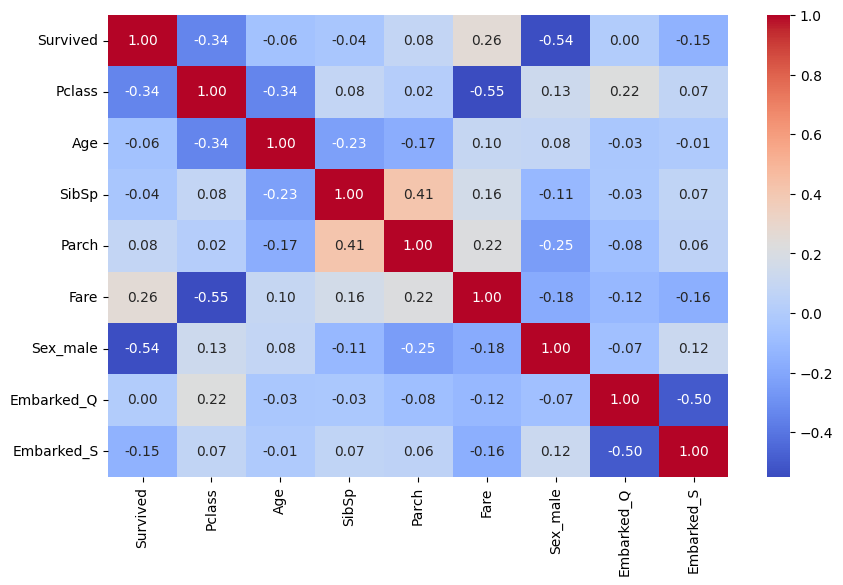


Most Correlated Features: ('Pclass', 'Fare')



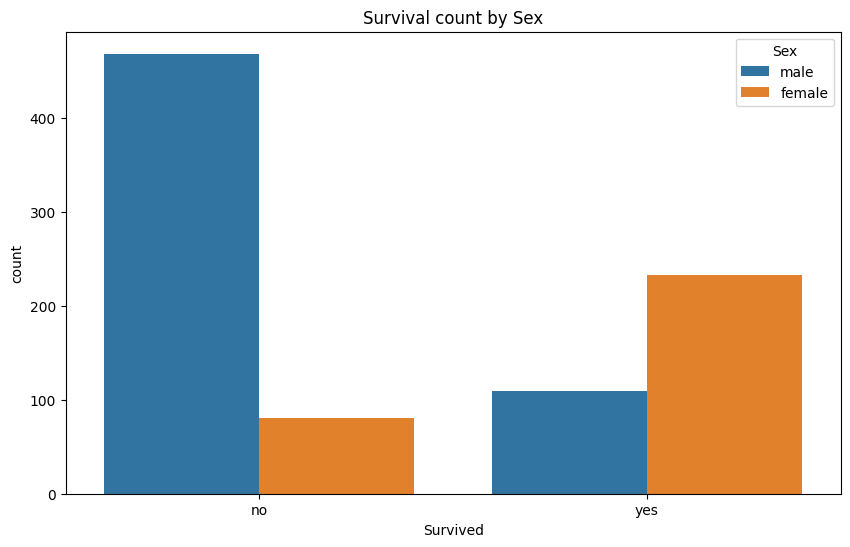

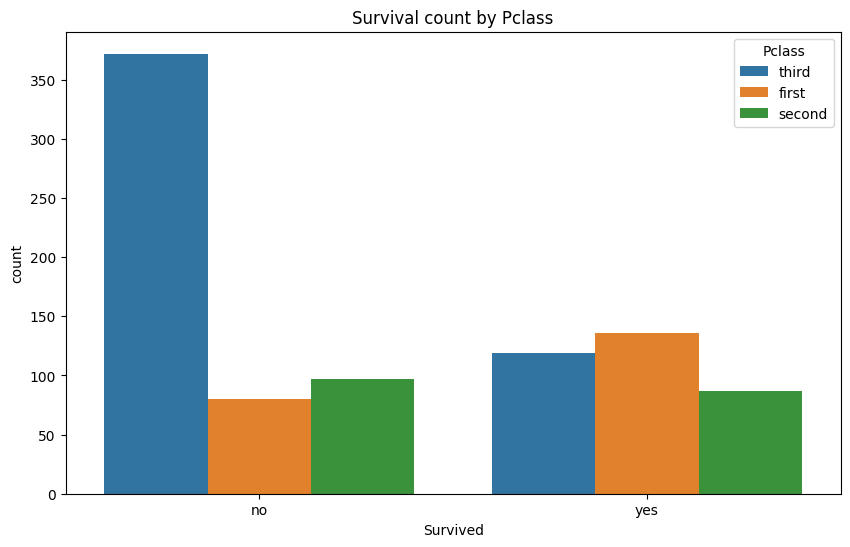

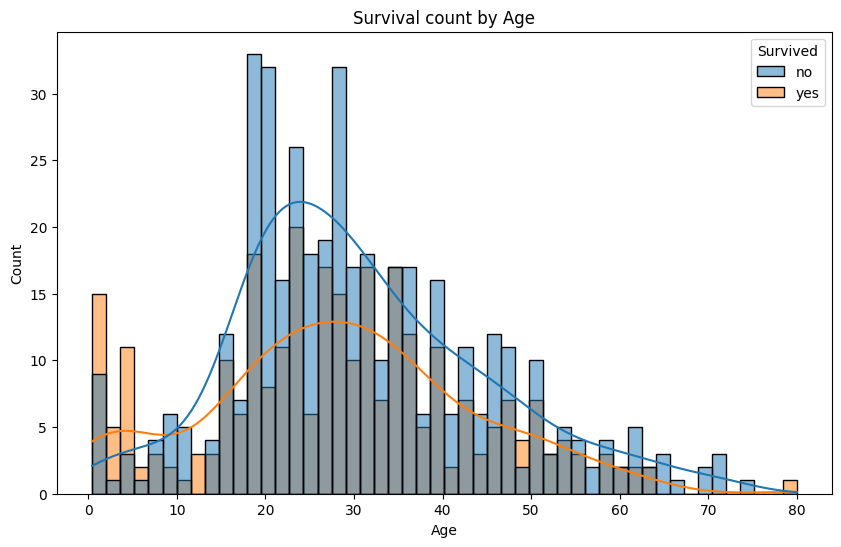

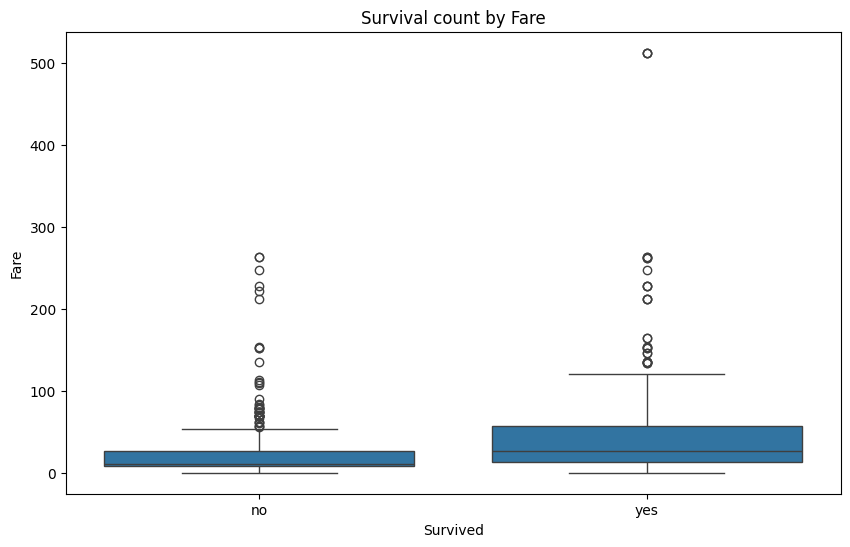

In [52]:
# Load dataset
df_titanic = pd.read_csv('titanic_data_updated.csv')

# How many features?
print(df_titanic.shape)

print()

# How many data points?
print(df_titanic.shape[0])

print()

# Is there any null values?
print(df_titanic.isnull().sum())

print()

# What kind of features are in your dataset? (Quantitative / Categorical)
num_val = df_titanic.select_dtypes(include = ['int64', 'float64']).columns
cat_val = df_titanic.select_dtypes(include = 'object').columns
print('Numeric / Quantitative Features:', list(num_val))
print('Categorical Features:', list(cat_val))

print()

df_copy = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

df_copy['Age'] = df_copy['Age'].fillna(df_copy['Age'].median())
df_copy['Embarked'] = df_copy['Embarked'].fillna(df_copy['Embarked'].mode()[0])

df_copy_encoded = pd.get_dummies(df_copy, columns = ['Sex', 'Embarked'], drop_first = True)
df_copy_encoded['Pclass'] = df_copy_encoded['Pclass'].map({'first': 1, 'second': 2, 'third': 3})
df_copy_encoded['Survived'] = df_copy_encoded['Survived'].map({'no': 0, 'yes': 1})

# Correlation of all the features, What do you understand after the correlation test?
corr_matrix = df_copy_encoded.corr()

plt.figure(figsize = (10, 6))
sns.heatmap(corr_matrix, annot = True, cmap = 'coolwarm', fmt = '.2f')
plt.show()

print()

most_corr = corr_matrix.copy()
np.fill_diagonal(most_corr.values, 0)
correlated = most_corr.abs().stack().sort_values(ascending = False).index[0]
print('Most Correlated Features:', correlated)

print()

# Perform exploratory data analysis to extract some important relationships from your data.
plt.figure(figsize = (10, 6))
sns.countplot(data = df_titanic, x = 'Survived', hue = 'Sex').set_title('Survival count by Sex')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.countplot(data = df_titanic, x = 'Survived', hue = 'Pclass').set_title('Survival count by Pclass')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.histplot(data = df_titanic, x = 'Age', hue = 'Survived', kde = True, bins = 50).set_title('Survival count by Age')
plt.show()

print()

plt.figure(figsize = (10, 6))
sns.boxplot(data = df_titanic, x = 'Survived', y = 'Fare').set_title('Survival count by Fare')
plt.show()

## Answer:

### How many features?
- Ans: It has total 12 features although the passengerId is an identifier and the Survived column is a target column so in this scenario, the actual input features are 10 excluding these two.

### Classification or regression problem? Why do you think so?
- Ans: This dataset is a classification problem because the target feature "Survived" is a binary column which is a classification problem.

### How many data points?
- Ans: It has 891 datapoints

### Is there any null values?
- Ans: Yes. There are 177 null values for Age, 687 for Cabin and 2 null values for Embarked.

### What kind of features are in your dataset? (Quantitative / Categorical)
- Ans: There are both categorical and quantitative data in the dataset.
Quantitative / Numerical : Age, SibSp, Parch, Fare and passengerId although it is an identifier.
Catogorical : Survived, Pclass, Name, Sex, Ticket, Cabin, Embarked although Survived is the target column.

### Do you need to encode the categorical variables, why or why not?
- Ans: Yes I need to encode the categorical variables. The categorical variables are objects or string in this dataset which the ML algorigthm can't understand directly. The algorithm understand the mathematical inputs. If I try to train a model with the raw object or string this will throw an error or unreliable result. And that's why I need to properly encode the catgorical varibales in the preprocessing steps.

### Correlation of all the features, What do you understand after the correlation test?
- The most correlated features are PClass and Fare which makes sense since higher class tickets cost more. Also, the survived feature is also correlated with Sex_male, pclass and Fare which indicates the survival rate by different ratio. Overall, the correlation test illustrates that the most correlated features are sex, pclass, fare and other features are seemingly moderately correlated.

### Perform exploratory data analysis to extract some important relationships from your data.

- From the EDA, I can observe that:
  - The female survived more than male
  - The lowest survival rate is for third pclass
  - The young passengers especially children survived more than older passengers
  - The survival rate is higher for the high fares.

#2. Dataset pre-processing (15 marks)

1. Provide code
2. Discuss the pre processing steps you applied and why?


## Answer:


   

In [53]:
df_copy = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis = 1)

num_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'median')),
        ('scaler', StandardScaler())
    ]
)

cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy = 'most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, drop = 'first', handle_unknown = 'ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers = [
        ('ordinal', OrdinalEncoder(categories=[['first', 'second', 'third']]), ['Pclass']),
        ('num', num_pipeline, ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']),
        ('cat', cat_pipeline, ['Sex', 'Embarked'])
    ]
)

preprocessor

ColumnTransformer(transformers=[('ordinal',
                                 OrdinalEncoder(categories=[['first', 'second',
                                                             'third']]),
                                 ['Pclass']),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize',
                                  'IsAlone']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Sex', 'Embarked'])])

### Discuss the pre processing steps you applied and why?
- Hence are discussed the preprocessing steps applied and why:
  - First, I dropped PassengerId, Name, Ticket, and Cabin from the dataset. PassengerId is just a row identifier with no predictive value. Name is irrelevant to survival. Ticket is a mixture of string and numeric values with no clean structure to extract. Cabin has too many null values to reliably impute or use.

  - Then I created a numerical pipeline for the numerical features such as Age, SibSp, Parch, Fare. I used SimpleImputer with the median strategy, since median is more robust to outliers than mean, a few very high fares or ages wouldn't skew the median the way they would the mean. I then used StandardScaler to scale the values, centering them around 0 with unit variance. This matters because features like Age and Fare are on very different numeric ranges, and models sensitive to feature scale which can be biased toward whichever feature has the largest raw magnitude if left unscaled.

  - I also created a categorical pipeline for the categorical features such as Sex, Embarked. I used the most-frequent strategy in the imputer since these are object values, and mean/median don't apply. I used OneHotEncoder to encode them, with handle_unknown = 'ignore' to avoid errors if an unseen category shows up at prediction time. Sex and Embarked don't have any natural order, so one-hot encoding is appropriate for them unlike Pclass, which does have a meaningful order, so I encoded that one with OrdinalEncoder instead.

  - In the ColumnTransformer step, I combined all three: the ordinal encoder for Pclass and for this section, the numeric pipeline, and the categorical pipeline, into a single preprocessor.

  - Wrapping everything in a single ColumnTransformer / Pipeline means missing value handling, scaling, and encoding are all applied consistently in one step, rather than repeating the logic manually every time the data needs to be transformed and it also avoids data leakage later, since the same fitted transformer can be applied to train and test sets consistently.

#3.Feature selection and Dataset splitting (10 marks)

1. Which features you wanna keep ? Justify and drop and rest or apply any other feature engineering step
2. Perform Train test split

## Answer:



### Which features you wanna keep ?
- I wanna keep all the features excluding PassengerId, Name, Ticket, Cabin and Survived. Because the PassengerId is identifier, Name is string value which is irrelevant. Ticket is a mixture of string and num value which is also irrelevant, Cabin has too many null values, Survived is the target variable. I also engineered two new features: FamilySize (SibSp + Parch + 1) and IsAlone (whether FamilySize equals 1), since total family group size and traveling alone are both known to relate to survival outcome beyond what the raw SibSp/Parch counts capture individually.

In [54]:
# drop and rest or apply any other feature engineering step
X = df_titanic.drop(['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'], axis = 1)
y = df_titanic['Survived']

X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
X['IsAlone'] = (X['FamilySize'] == 1).astype(int)

# Perform Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify = y)

#4.  Pipeline Creation (Supervised) (10 marks)

Select 2 models of your choice and build 2 pipelines for them

## Answer:

In [55]:
# Select 2 models of your choice and build 2 pipelines for them

#KNN model
knn_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('knn', KNeighborsClassifier())
    ]
)

knn_grid = {
    'knn__n_neighbors': [1, 3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_search_knn = GridSearchCV(
    estimator = knn_pipeline,
    param_grid = knn_grid,
    cv = 3,
    n_jobs = -1
)


#SVC Model
svc_pipeline = Pipeline(
    steps = [
        ('preprocessor', preprocessor),
        ('svc', SVC())
    ]
)

svc_grid = {
    'svc__kernel': ['rbf'],
    'svc__C': [0.1, 1.0],
    'svc__gamma': ['scale', 'auto']
}

grid_search_svc = GridSearchCV(
    estimator = svc_pipeline,
    param_grid = svc_grid,
    cv = 3,
    n_jobs = -1
)

# 5. Model Training (5 marks)

Train those 2 models



## Answer:

In [56]:
# Train those 2 models
grid_search_knn.fit(X_train, y_train)

best_model_knn = grid_search_knn.best_estimator_
y_pred_knn = best_model_knn.predict(X_test)

grid_search_svc.fit(X_train, y_train)
y_pred_svc = grid_search_svc.predict(X_test)

#6. Model selection/Comparison analysis (15 marks)
* Bar chart showcasing prediction accuracy of all models (for classification)
* Precision, recall comparison of each model. (for classification)
* Confusion Matrix (for classification)
* R2 score and Loss  (for regression)

Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?

# Answer:

Accuracy: (KNN) = 0.78, (SVC) = 0.83

KNN Classification Report
              precision    recall  f1-score   support

          no       0.80      0.85      0.82       110
         yes       0.73      0.67      0.70        69

    accuracy                           0.78       179
   macro avg       0.77      0.76      0.76       179
weighted avg       0.77      0.78      0.77       179


SVC Classification Report
              precision    recall  f1-score   support

          no       0.84      0.89      0.86       110
         yes       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



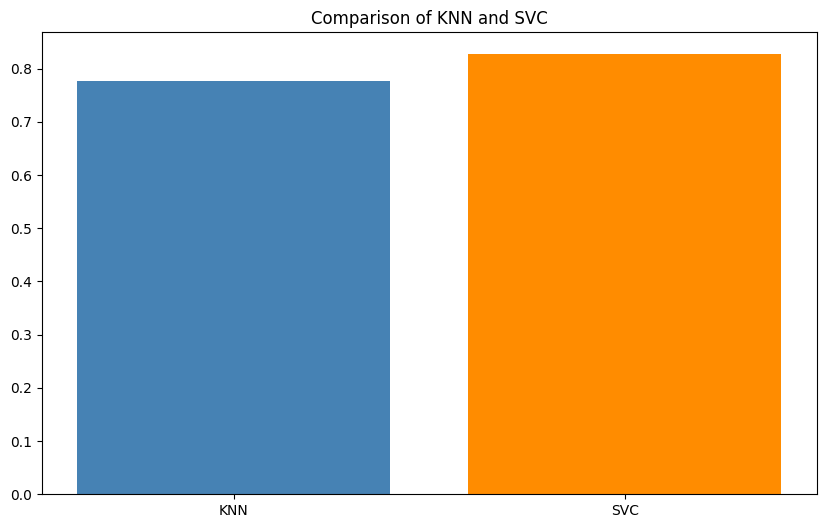

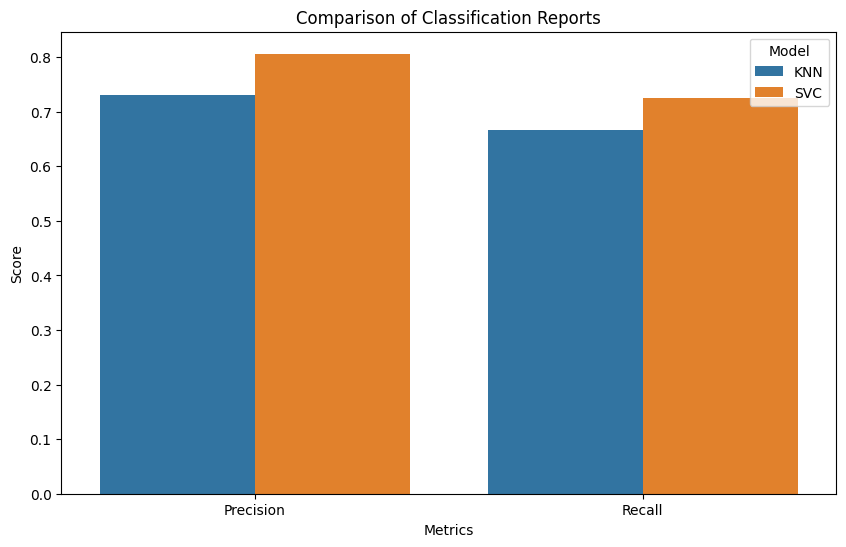

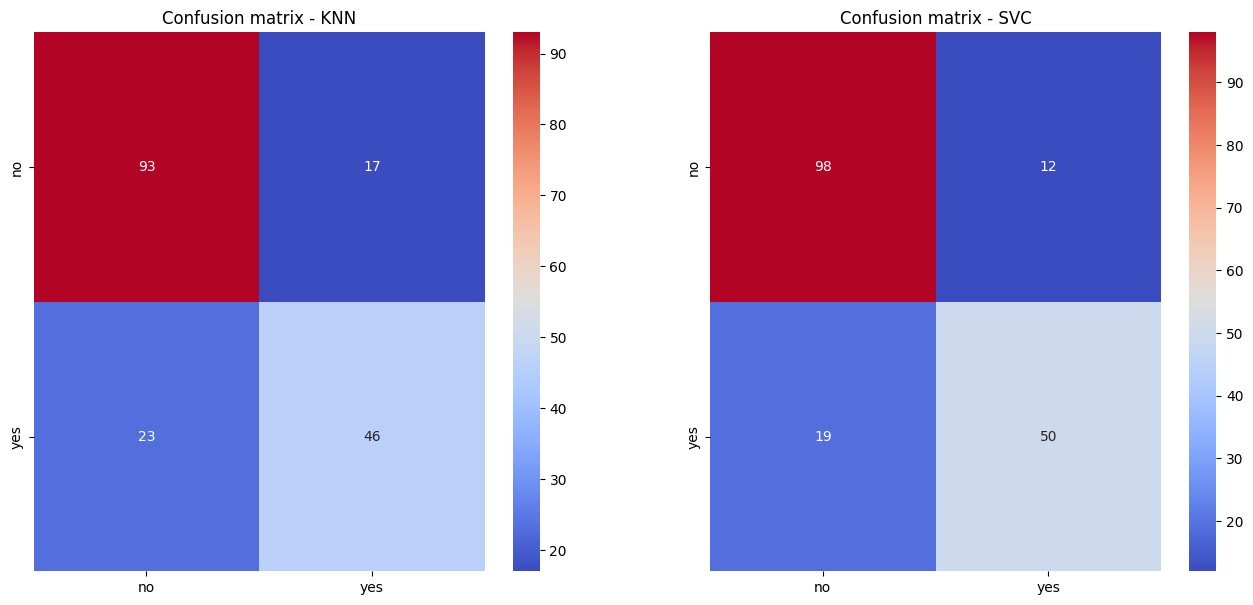

In [57]:
# Bar chart showcasing prediction accuracy of all models (for classification)
knn_acc = accuracy_score(y_test, y_pred_knn)
svc_acc = accuracy_score(y_test, y_pred_svc)

print(f'Accuracy: (KNN) = {round(knn_acc, 2)}, (SVC) = {round(svc_acc, 2)}')

print()

print('KNN Classification Report')
print(classification_report(y_test, y_pred_knn))

print()

print('SVC Classification Report')
print(classification_report(y_test, y_pred_svc))

plt.figure(figsize = (10, 6))
plt.bar(['KNN', 'SVC'], [knn_acc, svc_acc], color = ['steelblue', 'darkorange'])
plt.title('Comparison of KNN and SVC')
plt.show()

print()

# Precision, recall comparison of each model. (for classification)
knn_class = classification_report(y_test, y_pred_knn, output_dict = True)
svc_class = classification_report(y_test, y_pred_svc, output_dict = True)

comp_metrics = pd.DataFrame({
    'Model': ['KNN', 'KNN', 'SVC', 'SVC'],
    'Metrics': ['Precision', 'Recall', 'Precision', 'Recall'],
    'Score': [
        knn_class['yes']['precision'], knn_class['yes']['recall'],
        svc_class['yes']['precision'], svc_class['yes']['recall']

    ]
})

plt.figure(figsize = (10, 6))
sns.barplot(data = comp_metrics, x = 'Metrics', y = 'Score', hue = 'Model').set_title('Comparison of Classification Reports')
plt.show()

print()

# Confusion Matrix (for classification)
conf_knn = confusion_matrix(y_test, y_pred_knn, labels = ['no', 'yes'])
conf_svc = confusion_matrix(y_test, y_pred_svc, labels = ['no', 'yes'])

fig, axes = plt.subplots(1, 2, figsize = (16, 7))

sns.heatmap(conf_knn, cmap = 'coolwarm', annot = True, xticklabels = ['no', 'yes'], yticklabels = ['no', 'yes'], ax = axes[0])
axes[0].set_title('Confusion matrix - KNN')

sns.heatmap(conf_svc, cmap = 'coolwarm', annot = True, xticklabels = ['no', 'yes'], yticklabels = ['no', 'yes'], ax = axes[1])
axes[1].set_title('Confusion matrix - SVC')

plt.show()

### R2 score and Loss (for regression)
- Ans: the R2 score and Loss are not applicable here because the titanic dataset i chose is a classification problem, not regression problem dataset.

### Compare the results of all models based on all of the above described metrics. Why do you think this model performed better than the other one for this dataset?
- Ans:
  - COMPARISON: From the test I observe that the accuracy score of SVC (0.83) is greater than KNN model (0.78). The classification report shows that the knn model has 0.73 precision, 0.67 precision, and 0.70 f1-score. On the other hand the classification report for SVC showcased that, 0.81 precision, 0.72 recall, 0.76 f1-score The heatmap shows the graphical interpretation of the confusion matrix in which I see that the svc model predicts the survival rate more accurately than knn model.

  - JUSTIFICATION: I think that the svc model outperformed knn because the svc build a global decision boundary that capture the non-linear relationships in the dataset. but knn predicts based on the nearest neighbor or data point in the dataset which can be misleading because of outliers and imbalance dataset without proper preprocessing.

# 7. Treating the problem as Unsupervised (20 marks) ( Explore the topic as you wish )

1. Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
2. Which method worked better? supervised or unsupervised approach and why?

# Answer:

Components kept: 7
Explained Ratio: [0.4397698  0.20824619 0.10736007 0.08194725 0.06051383 0.04109108
 0.03017208]
Cumulative Variance: [0.4397698  0.64801598 0.75537605 0.8373233  0.89783713 0.93892822
 0.9691003 ]

ARI Score: 0.06
NMI Score: 0.03


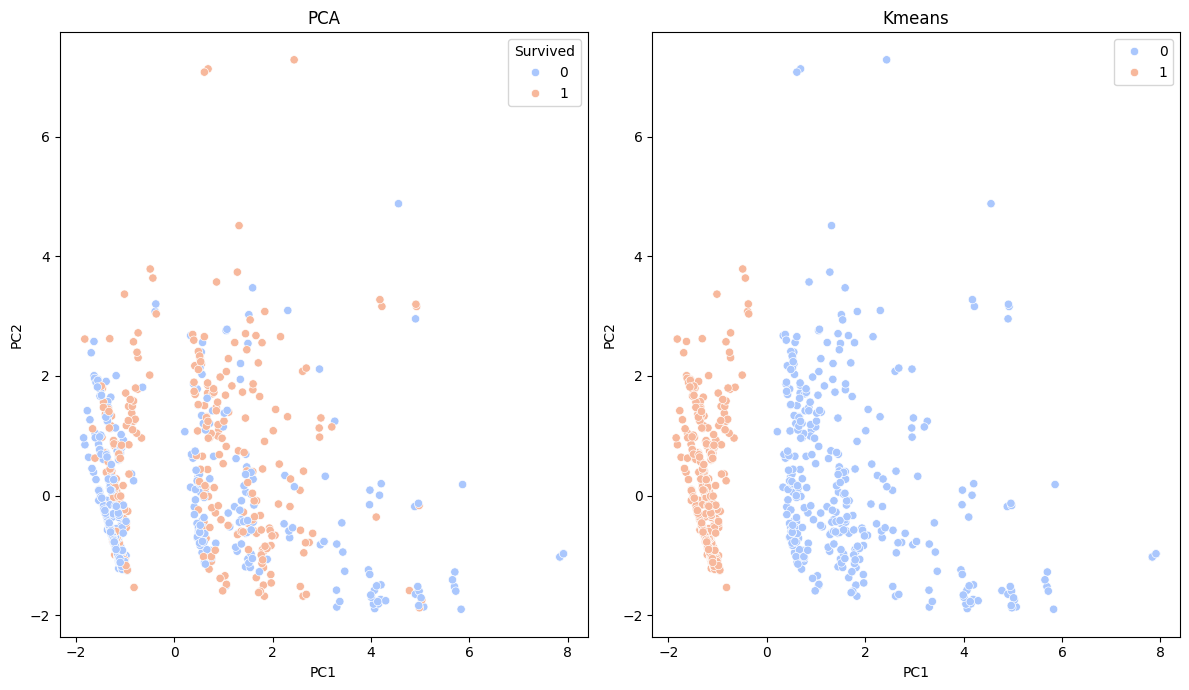

In [58]:
# Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
X_pca_transformed = preprocessor.fit_transform(X)
y_encoded = y.map({'no': 0, 'yes': 1})

np.set_printoptions(suppress = True)

pca = PCA(n_components = 0.95)
X_pca = pca.fit_transform(X_pca_transformed)

explained = pca.explained_variance_ratio_
cum_variance = np.cumsum(explained)

print('Components kept:', X_pca.shape[1])
print('Explained Ratio:', explained)
print('Cumulative Variance:', cum_variance)

print()

kmeans = KMeans(n_clusters = 2, init = 'k-means++', max_iter = 400, random_state = 42)
clusters = kmeans.fit_predict(X_pca)

ari_score = adjusted_rand_score(y_encoded, clusters)
nmi_score = normalized_mutual_info_score(y_encoded, clusters)

print('ARI Score:', round(ari_score, 2))
print('NMI Score:', round(nmi_score, 2))

fig, axes = plt.subplots(1, 2, figsize = (12, 7))

sns.scatterplot(x = X_pca[:, 0], y = X_pca[:, 1], hue = y_encoded, palette = 'coolwarm', ax = axes[0])
axes[0].set_title('PCA')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

sns.scatterplot(x = X_pca[:, 0], y = X_pca[:, 1], hue = clusters, palette = 'coolwarm', ax = axes[1])
axes[1].set_title('Kmeans')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

### Treat the problem as a unsupervised problem and perform any unsupervised model and evalute the result
 - Ans: At first I ran PCA on this dataset and used n_components = 0.95 so that it use the required components for 95% of total data. Then i ran kmeans with n_clusters = 2 on these pca components. As the kmeans does't use labels I used ARI and NMI scores to evaluate against the true survival values. I found that the ARI score provides 0.06 and NMI provides 0.03 which indicates that the kmeans barely match the actual survival groups.

### Which method worked better? supervised or unsupervised approach and why?
- Ans: The supervised method worked better than unsupervised method. In the supervised method I observed that the svc provides accuracy of 0.83 and KNN provides 0.78 whereas in the unsupervised method the kmeans clustering barely matched actual survival group. From the ARI and NMI I see that it only provides score 0.06 and 0.03 which is barely any effective output for this dataset. The tuning of hyperparameters in supervised learning helps the model to actually predict the survival rate of this dataset.

#8. Self Reflection on this machine learning course (10 marks)

Explain the hardest and the easiest topic of this course according to you in a intuitive way (you may also provide real world implementation , necessity etc along with the explaination)

##Answer:

# The Hardest:
- In this Machine Learning course, I found clustering difficult at first. I had to research KMeans clustering along with the elbow method and silhouette score to figure out how to choose the right number of clusters for a dataset. From the module alone I got the general idea, but I had to go through the documentation properly to actually understand it. In the real world, clustering is a very important method because it helps find structure and groups in unlabeled data for example, segmenting customers by behavior or grouping similar data points when there are no predefined categories to classify against.

# The Easiest:
- I found the feature engineering and train test split most easiest. At first I didn't understand why these are needed and how to do it properly but after couples of modules and practices I learned that it is the very first step to train a model. In the real world, datasets often have missing values, imbalanced classes, or features on very different scales. The preprocessing and feature engineering steps handles these issues properly like handling missing values, encoding, scaling, splitting for train and test etc so the model is trained on clean and well prepared data.